In [1]:
# import dependencies
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.ticker import FuncFormatter
import os
import subprocess, pathlib

### Note:
The image exporter taking snapshots of the Leaflet map (run at the end of this notebook) saves images to docs/static/images, so any images used elsewhere (i.e., README.md) must be manually copied and pasted.

In [2]:
# color palettes
quadrant_colors = {
    "zero_funding": "#888888",  # gray for absent/unknown feels right
    "underfunded": "#d55e00",  # vermilion — warm alarm, not pure red, CVD-distinguishable
    "aligned": "#0072b2",  # deep blue — matches dashboard primary theme (#0085a1)
    "overfunded": "#cc79a7",  # mauve/pink — distinct from vermilion under CVD
    "low_priority": "#e69f00",  # amber — warm but lower urgency than vermilion
}

In [3]:
# open geojson file
gdf = gpd.read_file("../docs/static/resources/town_boundaries.geojson")

# open town stats file
df = pd.read_csv("../docs/static/resources/town_stats.csv")

# open hma data
df_hma = pd.read_csv("../data/cleaned/fema_hma_projects_clean.csv")

In [4]:
# remove "State of Vermont" from df
df = df[df.town_name != "State of Vermont"].copy()

In [5]:
# # merge stats onto geometry, using GEOID as the key
# df['GEOID']  = df['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
# gdf['GEOID'] = gdf['GEOID'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# # check for mismatches in the key before merging
# # df_keys = set(df['GEOID'])
# # gdf_keys = set(gdf['GEOID'])
# # missing_in_gdf = df_keys - gdf_keys
# # if missing_in_gdf:
# #     print(f"Warning: {len(missing_in_gdf)} GEOIDs in df not found in gdf. Sample: {list(missing_in_gdf)[:5]}")
# # perform the merge
# gdf_merged = gdf.merge(df, on=['GEOID', 'town_name'], how='left', suffixes=('', '_stats'))
# gdf_merged.columns

In [6]:
## get total FEMA HMA funding, all time, nationally
#
#  open all fema hma projects
all_hma = pd.read_csv("../data/raw/funding/HazardMitigationAssistanceProjects.csv")
all_hma.columns

# open CPI csv and calculate annual average CPI values for each year
cpi = pd.read_csv("../data/resources/CPIAUCSL.csv")
cpi["DATE"] = pd.to_datetime(cpi["observation_date"])
cpi["year"] = cpi["DATE"].dt.year
cpi_annual = cpi.groupby("year")["CPIAUCSL"].mean().reset_index()
# display(cpi_annual.tail())

# get most recent full year
reference_year = cpi_annual["year"].max()
if pd.Timestamp.now().year == reference_year:
    reference_year -= 1
cpi_ref = cpi_annual.loc[cpi_annual["year"] == reference_year, "CPIAUCSL"].values[0]
# print(f"Reference year: {reference_year}, CPI: {cpi_ref:.4f}")

# create a CPI lookup dictionary
cpi_lookup = dict(zip(cpi_annual["year"], cpi_annual["CPIAUCSL"]))
# calculate adjustment factors for each year in the dataset
# adjustment factor = CPI in reference year / CPI in project year
cpi_factors = {year: cpi_ref / cpi_value for year, cpi_value in cpi_lookup.items()}
# print("CPI adjustment factors:")
# for year, factor in cpi_factors.items():
#     print(f"{year}: {factor:.4f}")

# apply adjustment to each row
all_hma["federalShareObligated_adj"] = all_hma.apply(
    # inflation adjusted amount = nominal amount * (CPI in reference year / CPI in project year)
    lambda row: row["federalShareObligated"] * cpi_factors.get(row["programFy"], 1.0),
    axis=1,
)

# sum adjusted funding
print("Total FEMA HMA spending (all projects):")
print(f"Funding in {reference_year} dollars:")
print(f"Total nominal funding: ${all_hma['federalShareObligated'].sum():,.2f}")
print(
    f"Total inflation-adjusted funding: ${all_hma['federalShareObligated_adj'].sum():,.2f}"
)

Total FEMA HMA spending (all projects):
Funding in 2025 dollars:
Total nominal funding: $21,118,862,807.21
Total inflation-adjusted funding: $31,665,956,768.18


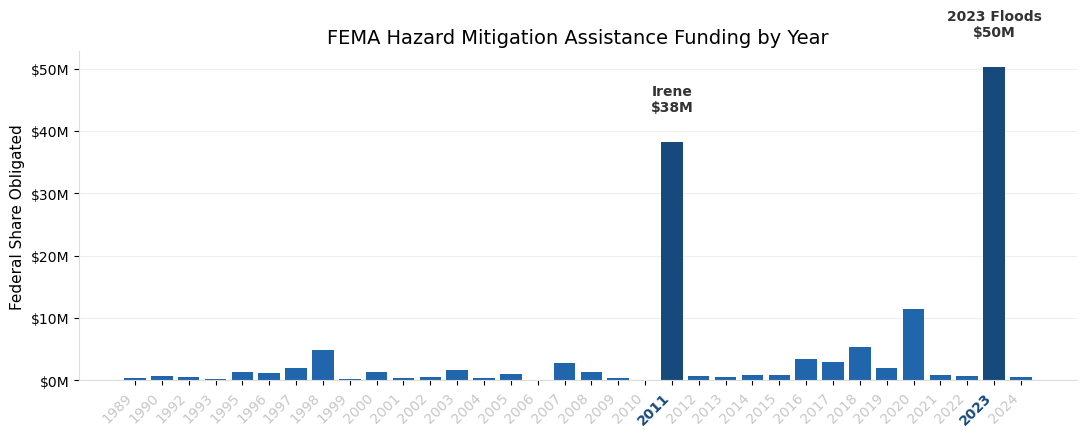

In [7]:
# ------------------------------------------------------------------
# Shared article styling
# ------------------------------------------------------------------

BLUE = "#2166ac"
GRAY = "#c7c7c7"
DARK = "#333333"
HIGHLIGHT = "#174a7c"  # darker blue for disaster years

plt.style.use("default")

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.edgecolor": "#dddddd",
    }
)

# ------------------------------------------------------------------
# FEMA HMA Funding by Year
# ------------------------------------------------------------------

funding_by_year = (
    df_hma.groupby("programFy")["federalShareObligated_adj"].sum().sort_index()
)

years = funding_by_year.index.astype(str)
values = funding_by_year.values

colors = [BLUE] * len(years)

for i, year in enumerate(years):
    if year in ["2011", "2023"]:
        colors[i] = HIGHLIGHT

fig, ax = plt.subplots(figsize=(11, 4.5))

bars = ax.bar(years, values, color=colors)

# Irene annotation
if "2011" in years:
    idx = list(years).index("2011")
    val = values[idx]

    # ax.axvline(idx, color="#999999", linestyle="--", linewidth=1)

    ax.annotate(
        f"Irene\n${val/1e6:.0f}M",
        xy=(idx, val),
        xytext=(0, 20),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color=DARK,
        fontweight="bold",
    )

# July 2023 Floods annotation
if "2023" in years:
    idx = list(years).index("2023")
    val = values[idx]

    # ax.axvline(idx, color="#999999", linestyle="--", linewidth=1)

    ax.annotate(
        f"2023 Floods\n${val/1e6:.0f}M",
        xy=(idx, val),
        xytext=(0, 20),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        color=DARK,
        fontweight="bold",
    )

ax.set_title("FEMA Hazard Mitigation Assistance Funding by Year")
ax.set_ylabel("Federal Share Obligated")
ax.set_xlabel("")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

# rotate x labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
# emphasize 2011 and 2023 x labels, deemphasize others
for tick in ax.get_xticklabels():
    if tick.get_text() in ["2011", "2023"]:
        tick.set_color(HIGHLIGHT)
        tick.set_fontweight("bold")
    else:
        tick.set_color(GRAY)

ax.grid(axis="y", color="#eeeeee")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../docs/static/images/funding_by_year.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

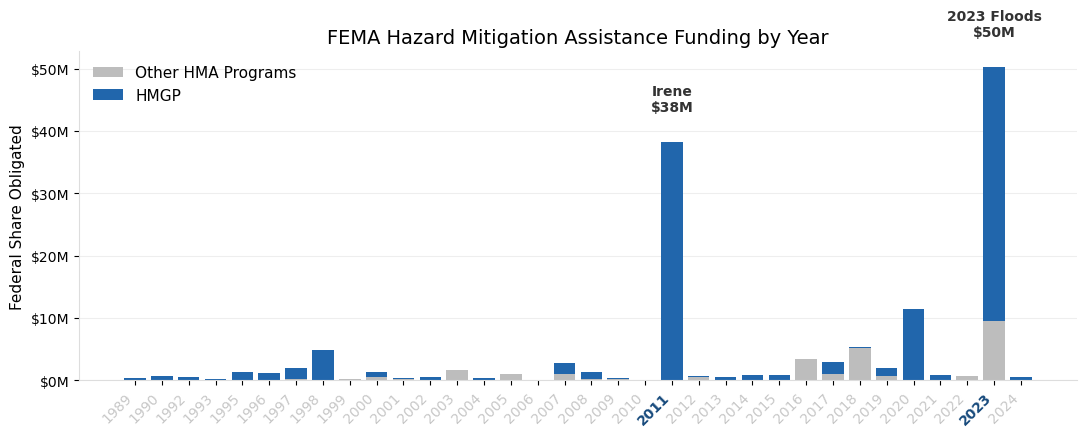

In [8]:
# ------------------------------------------------------------------
# FEMA HMA Funding by Year (HMGP vs Other)
# ------------------------------------------------------------------

funding_by_year = (
    df_hma.assign(
        funding_type=np.where(
            df_hma["programArea"] == "HMGP",
            "HMGP",
            "Other HMA",
        )
    )
    .groupby(["programFy", "funding_type"])["federalShareObligated_adj"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

years = funding_by_year.index.astype(str)

fig, ax = plt.subplots(figsize=(11, 4.5))

# colors
HMGP_COLOR = "#2166ac"
OTHER_COLOR = "#bdbdbd"

bars_other = ax.bar(
    years,
    funding_by_year["Other HMA"],
    color=OTHER_COLOR,
    label="Other HMA Programs",
)

bars_hmgp = ax.bar(
    years,
    funding_by_year["HMGP"],
    bottom=funding_by_year["Other HMA"],
    color=HMGP_COLOR,
    label="HMGP",
)

# annotate disaster years using total funding
totals = funding_by_year.sum(axis=1)

for disaster_year, label in [
    ("2011", "Irene"),
    ("2023", "2023 Floods"),
]:
    if disaster_year in years:
        idx = list(years).index(disaster_year)
        val = totals.loc[int(disaster_year)]

        ax.annotate(
            f"{label}\n${val/1e6:.0f}M",
            xy=(idx, val),
            xytext=(0, 20),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            color=DARK,
            fontweight="bold",
        )

ax.set_title("FEMA Hazard Mitigation Assistance Funding by Year")
ax.set_ylabel("Federal Share Obligated")
ax.set_xlabel("")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

for tick in ax.get_xticklabels():
    if tick.get_text() in ["2011", "2023"]:
        tick.set_color(HIGHLIGHT)
        tick.set_fontweight("bold")
    else:
        tick.set_color(GRAY)

ax.grid(axis="y", color="#eeeeee")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

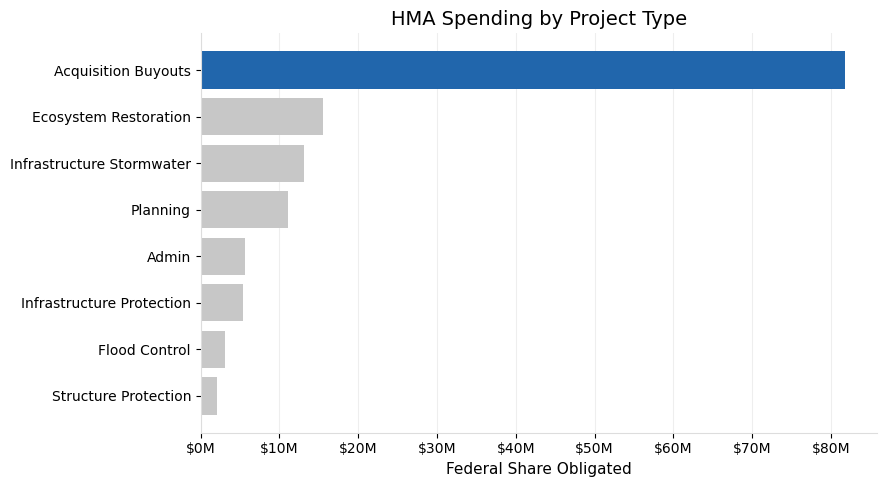

In [9]:
# ------------------------------------------------------------------
# Shared article styling
# ------------------------------------------------------------------

BLUE = "#2166ac"
GRAY = "#c7c7c7"
DARK = "#333333"
HIGHLIGHT = "#174a7c"  # darker blue for disaster years

plt.style.use("default")

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.edgecolor": "#dddddd",
    }
)

# ------------------------------------------------------------------
# HMA Funding by Project Type
# Emphasize acquisitions / buyouts
# ------------------------------------------------------------------

funding_cols = [
    col
    for col in df_hma.columns
    if col.startswith("funding_") and col not in ["funding_other", "funding_equipment"]
]

funding_df = df_hma[funding_cols].sum().reset_index()

funding_df.columns = ["Funding Type", "Amount"]

funding_df["Funding Type"] = (
    funding_df["Funding Type"]
    .str.replace("funding_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

funding_df = funding_df.sort_values("Amount", ascending=True)

# highlight acquisition / buyout category
colors = []

for category in funding_df["Funding Type"]:
    if "Acquisition" in category or "Buyout" in category:
        colors.append(BLUE)
    else:
        colors.append(GRAY)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    funding_df["Funding Type"],
    funding_df["Amount"],
    color=colors,
)

ax.set_title("HMA Spending by Project Type")
ax.set_xlabel("Federal Share Obligated")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

ax.grid(axis="x", color="#eeeeee")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../docs/static/images/funding_by_type.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3381186778.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("need_quintile")
C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3381186778.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("need_quintile")
C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3381186778.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("YlOrBr")


Saved


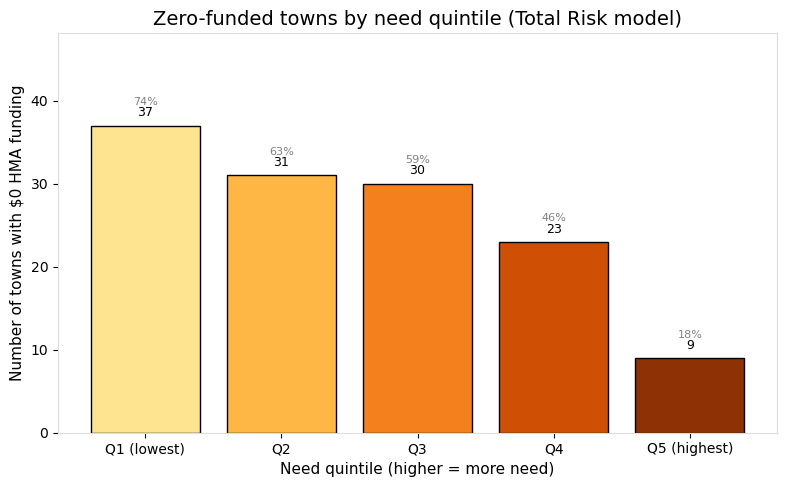

In [10]:
# Create bar chart of count of zero‑funding towns by need quintile (compute quintiles from need_rank_eal)

# !!!! EAL model!!!!!!!

# compute quintiles from need_rank_eal (0-1)
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
df["need_quintile"] = pd.cut(
    df["need_rank_eal"], bins=bins, labels=labels, include_lowest=True, right=True
)

# counts
total_by_q = (
    df.dropna(subset=["need_quintile"])
    .groupby("need_quintile")
    .size()
    .reindex(labels, fill_value=0)
)
zero_by_q = (
    df[df["funding_total"] == 0]
    .dropna(subset=["need_quintile"])
    .groupby("need_quintile")
    .size()
    .reindex(labels, fill_value=0)
)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.get_cmap("YlOrBr")
colors = cmap(np.linspace(0.25, 0.9, len(labels)))
bars = ax.bar(labels, zero_by_q.values, color=colors, edgecolor="k")

# annotate counts and percent of quintile that are zero-funded
pct = (zero_by_q / total_by_q.replace(0, np.nan) * 100).fillna(0)
for bar, count, p in zip(bars, zero_by_q.values, pct.values):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(0.4, 0.02 * max(zero_by_q.max(), 1)),
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(1.2, 0.06 * max(zero_by_q.max(), 1)),
        f"{p:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray",
    )

ax.set_xlabel("Need quintile (higher = more need)")
ax.set_ylabel("Number of towns with $0 HMA funding")
ax.set_title("Zero-funded towns by need quintile (Total Risk model)")
ax.set_ylim(0, max(zero_by_q.max() * 1.3, 5))
plt.tight_layout()

fig.savefig("../docs/static/images/zero_funding_by_quintile.png", bbox_inches="tight")
print("Saved")
plt.show()

C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3990432785.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("need_quintile")
C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3990432785.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("need_quintile")
C:\Users\johbr\AppData\Local\Temp\ipykernel_37452\3990432785.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("YlOrBr")


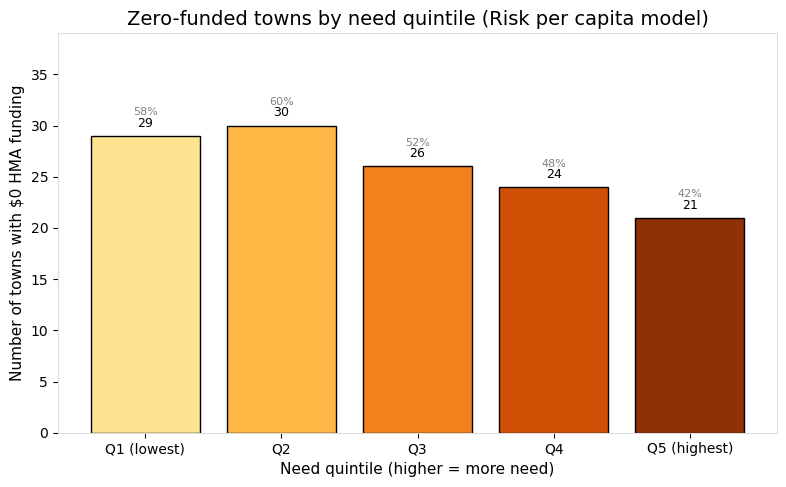

In [11]:
# Create bar chart of count of zero‑funding towns by need quintile (compute quintiles from need_rank_eal_per_capita)

# !!!! EAL per capita model!!!!!

# compute quintiles from need_rank_eal_per_capita (0-1)
bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"]
df["need_quintile"] = pd.cut(
    df["need_rank_eal_per_capita"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True,
)

# counts
total_by_q = (
    df.dropna(subset=["need_quintile"])
    .groupby("need_quintile")
    .size()
    .reindex(labels, fill_value=0)
)
zero_by_q = (
    df[df["funding_total"] == 0]
    .dropna(subset=["need_quintile"])
    .groupby("need_quintile")
    .size()
    .reindex(labels, fill_value=0)
)

# plot
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.cm.get_cmap("YlOrBr")
colors = cmap(np.linspace(0.25, 0.9, len(labels)))
bars = ax.bar(labels, zero_by_q.values, color=colors, edgecolor="k")

# annotate counts and percent of quintile that are zero-funded
pct = (zero_by_q / total_by_q.replace(0, np.nan) * 100).fillna(0)
for bar, count, p in zip(bars, zero_by_q.values, pct.values):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(0.4, 0.02 * max(zero_by_q.max(), 1)),
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(1.2, 0.06 * max(zero_by_q.max(), 1)),
        f"{p:.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="gray",
    )

ax.set_xlabel("Need quintile (higher = more need)")
ax.set_ylabel("Number of towns with $0 HMA funding")
ax.set_title("Zero-funded towns by need quintile (Risk per capita model)")
ax.set_ylim(0, max(zero_by_q.max() * 1.3, 5))
plt.tight_layout()

# fig.savefig('../docs/static/images/zero_funding_by_quintile.svg', format='svg', bbox_inches='tight')
# print('Saved')
plt.show()

In [12]:
df_hma.columns

Index(['projectIdentifier', 'programArea', 'programFy', 'disasterNumber',
       'projectCounties', 'projectType', 'status', 'subrecipient',
       'dateApproved', 'projectAmount', 'federalShareObligated',
       'costSharePercentage', 'benefitCostRatio', 'netValueBenefits',
       'numberOfFinalProperties', 'numberOfProperties',
       'federalShareObligated_adj', 'flood_mitigation_flag', 'subcategory',
       'acquisition_buyouts', 'admin', 'ecosystem_restoration', 'equipment',
       'flood_control', 'infrastructure_protection',
       'infrastructure_stormwater', 'other', 'planning',
       'structure_protection', 'funding_acquisition_buyouts', 'funding_admin',
       'funding_ecosystem_restoration', 'funding_equipment',
       'funding_flood_control', 'funding_infrastructure_protection',
       'funding_infrastructure_stormwater', 'funding_other',
       'funding_planning', 'funding_structure_protection', 'town_assigned',
       'geo_level'],
      dtype='object')

In [13]:
df_hma.town_assigned.value_counts()

town_assigned
PAWLET TOWN        16
MONTPELIER CITY    14
RUPERT TOWN        13
CAMBRIDGE TOWN     12
NORTHFIELD TOWN    12
                   ..
BENNINGTON TOWN     1
BARNARD TOWN        1
TUNBRIDGE TOWN      1
BRADFORD TOWN       1
GUILDHALL TOWN      1
Name: count, Length: 146, dtype: int64

In [14]:
# print df_hma.subrecipient.value_counts() for 2011 and 2023
print("Subrecipient counts for 2011:")
print(df_hma[df_hma["programFy"] == 2011]["town_assigned"].value_counts())

Subrecipient counts for 2011:
town_assigned
PAWLET TOWN         11
NORTHFIELD TOWN      7
HARTFORD TOWN        6
WARREN TOWN          5
STOCKBRIDGE TOWN     5
                    ..
PROCTOR TOWN         1
ARLINGTON TOWN       1
STAMFORD TOWN        1
ROCHESTER TOWN       1
ENOSBURGH TOWN       1
Name: count, Length: 71, dtype: int64


In [15]:
print("\nSubrecipient counts for 2023:")
print(df_hma[df_hma["programFy"] == 2023]["town_assigned"].value_counts())


Subrecipient counts for 2023:
town_assigned
MONTPELIER CITY      3
CAMBRIDGE TOWN       3
RICHMOND TOWN        2
WATERBURY TOWN       2
MARSHFIELD TOWN      1
TROY TOWN            1
RIPTON TOWN          1
HARDWICK TOWN        1
WARDSBORO TOWN       1
WESTON TOWN          1
MANCHESTER TOWN      1
HARTFORD TOWN        1
CHESTER TOWN         1
WOODSTOCK TOWN       1
TUNBRIDGE TOWN       1
WEST FAIRLEE TOWN    1
GREENSBORO TOWN      1
STOWE TOWN           1
MORRISTOWN TOWN      1
WOLCOTT TOWN         1
BARRE CITY           1
WALLINGFORD TOWN     1
FAIR HAVEN TOWN      1
CABOT TOWN           1
MIDDLESEX TOWN       1
SWANTON TOWN         1
Name: count, dtype: int64


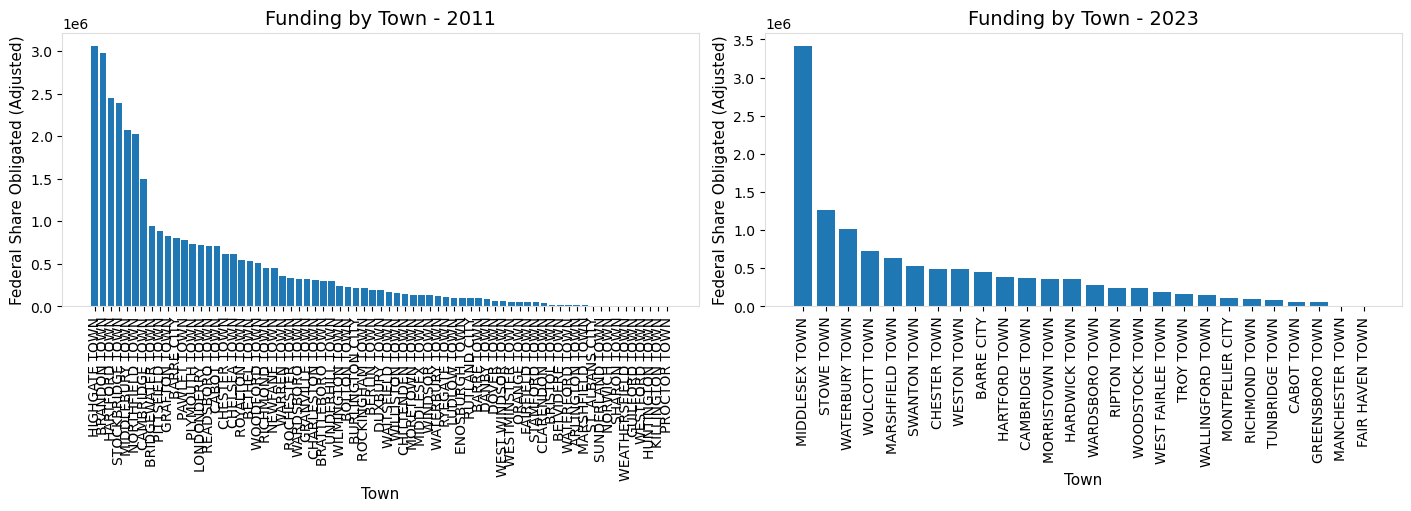

In [16]:
# sum federalShareObligated_adj by town_assigned for 2011 and 2023
funding_by_town_2011 = (
    df_hma[df_hma["programFy"] == 2011]
    .groupby("town_assigned")["federalShareObligated_adj"]
    .sum()
    .sort_values(ascending=False)
)
funding_by_town_2023 = (
    df_hma[df_hma["programFy"] == 2023]
    .groupby("town_assigned")["federalShareObligated_adj"]
    .sum()
    .sort_values(ascending=False)
)

# plot chorpleth of funding_by_town_2011 and funding_by_town_2023, side by side, with same scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# plot funding_by_town_2011
axes[0].bar(funding_by_town_2011.index, funding_by_town_2011.values)
axes[0].set_title("Funding by Town - 2011")
axes[0].set_xlabel("Town")
axes[0].set_ylabel("Federal Share Obligated (Adjusted)")
axes[0].tick_params(axis="x", rotation=90)

# plot funding_by_town_2023
axes[1].bar(funding_by_town_2023.index, funding_by_town_2023.values)
axes[1].set_title("Funding by Town - 2023")
axes[1].set_xlabel("Town")
axes[1].set_ylabel("Federal Share Obligated (Adjusted)")
axes[1].tick_params(axis="x", rotation=90)

plt.show()

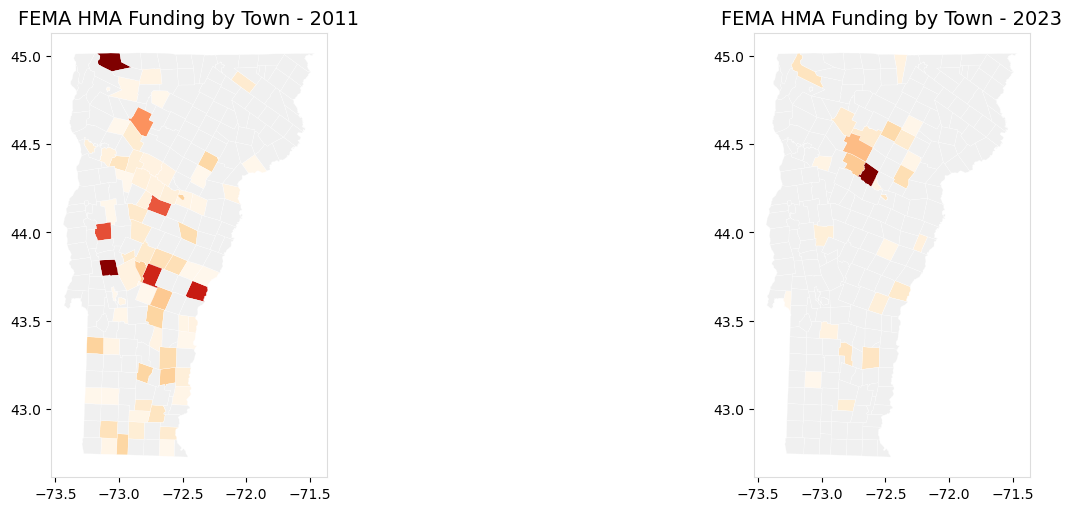

In [17]:
# rename town_assigned to town_name in funding_by_town_2011 and funding_by_town_2023 for merging
funding_by_town_2011.index.name = "town_name"
funding_by_town_2023.index.name = "town_name"

# Standardize town names to uppercase in both gdf and funding Series
gdf["town_name_upper"] = gdf["town_name"].str.upper()
funding_by_town_2011_upper = funding_by_town_2011.copy()
funding_by_town_2011_upper.index = funding_by_town_2011_upper.index.str.upper()
funding_by_town_2023_upper = funding_by_town_2023.copy()
funding_by_town_2023_upper.index = funding_by_town_2023_upper.index.str.upper()

# merge funding_by_town_2011 with gdf to plot choropleth of funding by town for 2011, then repeat for 2023
gdf_2011 = gdf.merge(
    funding_by_town_2011_upper.rename("funding_2011"),
    left_on="town_name_upper",
    right_index=True,
    how="left",
)
gdf_2023 = gdf.merge(
    funding_by_town_2023_upper.rename("funding_2023"),
    left_on="town_name_upper",
    right_index=True,
    how="left",
)

# plot choropleth of funding_2011 and funding_2023, side by side, with same scale
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
# plot funding_2011
gdf_2011.plot(
    column="funding_2011",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="white",
    ax=axes[0],
    missing_kwds={"color": "#f0f0f0"},
)
axes[0].set_title("FEMA HMA Funding by Town - 2011")

# plot funding_2023
gdf_2023.plot(
    column="funding_2023",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="white",
    ax=axes[1],
    missing_kwds={"color": "#f0f0f0"},
)
axes[1].set_title("FEMA HMA Funding by Town - 2023")

plt.show()

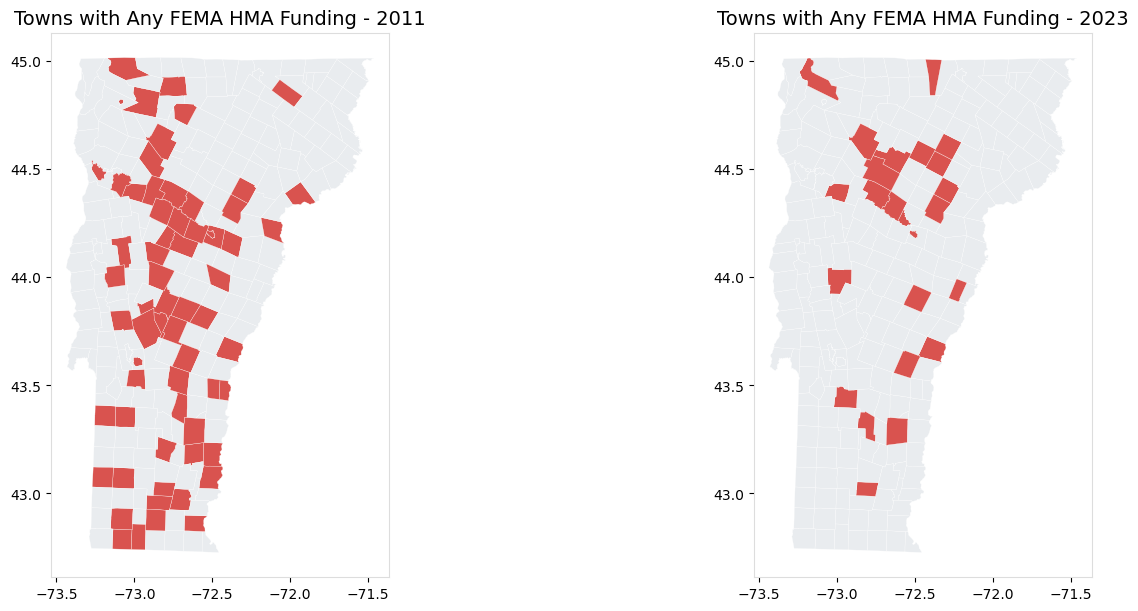

In [18]:
# Define custom colors: red for True (funded), grey for False (not funded)
funding_colors = {True: "#d9534f", False: "#e9ecef"}

# Add binary funded columns
gdf_2011["funded_2011"] = gdf_2011["funding_2011"].fillna(0) > 0
gdf_2023["funded_2023"] = gdf_2023["funding_2023"].fillna(0) > 0

# Map the colors to the funded column
gdf_2011["funded_2011_color"] = gdf_2011["funded_2011"].map(funding_colors)
gdf_2023["funded_2023_color"] = gdf_2023["funded_2023"].map(funding_colors)

# Plot with custom colors
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
gdf_2011.plot(
    color=gdf_2011["funded_2011_color"], linewidth=0.2, edgecolor="white", ax=axes[0]
)
axes[0].set_title("Towns with Any FEMA HMA Funding - 2011")
gdf_2023.plot(
    color=gdf_2023["funded_2023_color"], linewidth=0.2, edgecolor="white", ax=axes[1]
)
axes[1].set_title("Towns with Any FEMA HMA Funding - 2023")
plt.show()

In [19]:
# open nfip data and check town names
df_nfip = pd.read_csv("../data/cleaned/nfip_summary.csv")
df_nfip.columns

Index(['GEOID', 'town_name', 'total_population', 'occupied_housing_units',
       'nfip_claims', 'total_nfip_claims_paid', '2011_2022_nfip_claims',
       '2023_plus_nfip_claims', 'pre_2011_nfip_claims',
       '2011_2022_nfip_claims_count', '2023_plus_nfip_claims_count',
       'pre_2011_nfip_claims_count', 'claims_paid_per_capita',
       'claims_paid_per_housing_unit', 'irene_policies', 'flood2023_policies',
       'today_policies', 'current_insurance_penetration'],
      dtype='object')

Merged gdf with NFIP data. Columns:
 Index(['GEOID', 'town_name', 'geometry', 'town_name_upper', 'total_population',
       'occupied_housing_units', 'nfip_claims', 'total_nfip_claims_paid',
       '2011_2022_nfip_claims', '2023_plus_nfip_claims',
       'pre_2011_nfip_claims', '2011_2022_nfip_claims_count',
       '2023_plus_nfip_claims_count', 'pre_2011_nfip_claims_count',
       'claims_paid_per_capita', 'claims_paid_per_housing_unit',
       'irene_policies', 'flood2023_policies', 'today_policies',
       'current_insurance_penetration'],
      dtype='object')


Text(0.5, 1.0, 'NFIP Claims (2023+)')

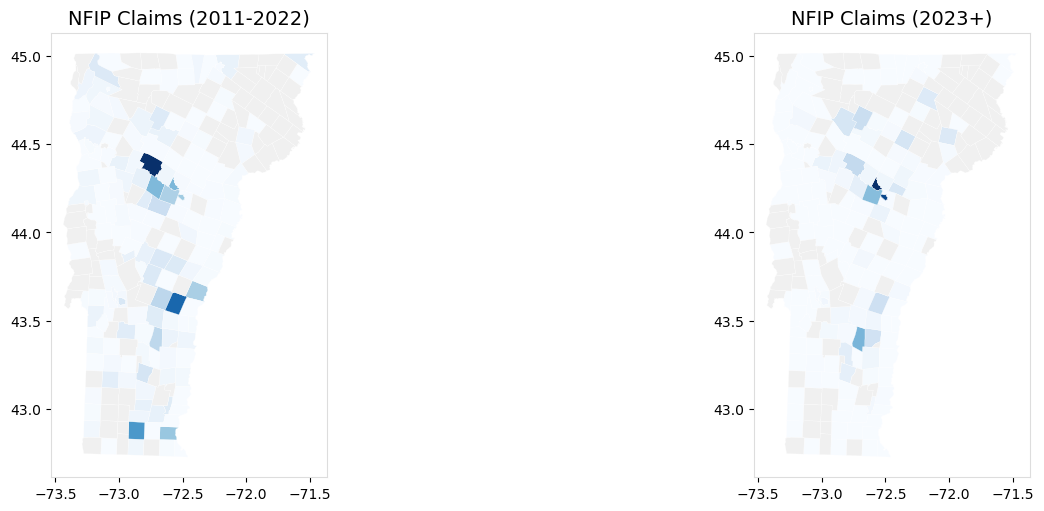

In [20]:
# convert GEOID to string
df_nfip["GEOID"] = (
    df_nfip["GEOID"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()
)
gdf["GEOID"] = gdf["GEOID"].astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

# convert town names to uppercase for merging
# df_nfip['town_name_upper'] = df_nfip['town_name'].str.upper()
# gdf['town_name_upper'] = gdf['town_name'].str.upper()

# merge with gdf to check town name matches
gdf_nfip = gdf.merge(
    df_nfip, on=["GEOID", "town_name"], how="left", suffixes=("", "_nfip")
)
print("Merged gdf with NFIP data. Columns:\n", gdf_nfip.columns)

# print choropleths of '2011_2022_nfip_claims' and '2023_plus_nfip_claims'
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
gdf_nfip.plot(
    column="2011_2022_nfip_claims",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="white",
    ax=axes[0],
    missing_kwds={"color": "#f0f0f0"},
)
axes[0].set_title("NFIP Claims (2011-2022)")
gdf_nfip.plot(
    column="2023_plus_nfip_claims",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="white",
    ax=axes[1],
    missing_kwds={"color": "#f0f0f0"},
)
axes[1].set_title("NFIP Claims (2023+)")

In [21]:
# export maps using node script export_maps.js
# (used in article.html)
proj = pathlib.Path.cwd().parent  # project root
subprocess.run(
    [
        "node",
        "scripts/export_maps.js",
        "--bases=need,quadrant",
        "--models=eal,eal_per_capita,nri",
    ],
    cwd=str(proj),
    check=True,
)
subprocess.run(
    [
        "node",
        "scripts/export_maps.js",
        "--bases=gap",
        "--models=eal,eal_per_capita,nri",
        "--relative=1",
    ],
    cwd=str(proj),
    check=True,
)

CompletedProcess(args=['node', 'scripts/export_maps.js', '--bases=gap', '--models=eal,eal_per_capita,nri', '--relative=1'], returncode=0)

In [22]:
# export maps using node script export_maps.js
# (used only in README - must manually copy/paste from docs/static/images to README resources/images)
proj = pathlib.Path.cwd().parent  # project root
subprocess.run(
    [
        "node",
        "scripts/export_maps.js",
        "--bases=risk",
        "--models=eal_per_capita",
    ],
    cwd=str(proj),
    check=True,
)
subprocess.run(
    [
        "node",
        "scripts/export_maps.js",
        "--bases=risk",
        "--models=eal_per_capita",
        "--relative=1",
    ],
    cwd=str(proj),
    check=True,
)
subprocess.run(
    [
        "node",
        "scripts/export_maps.js",
        "--bases=claims",
        "--models=eal_per_capita",
    ],
    cwd=str(proj),
    check=True,
)

CompletedProcess(args=['node', 'scripts/export_maps.js', '--bases=claims', '--models=eal_per_capita'], returncode=0)